# Bangkok Airbnb EDA
## What Makes a Successful Airbnb Listing in Bangkok?

**Dataset:** Inside Airbnb — Bangkok, Central Thailand (September 2025)  
**Files:** listings.csv.gz, calendar.csv.gz, reviews.csv.gz, neighbourhoods.geojson

### Guiding Questions
1. What drives listing price?
2. Which neighborhoods are most competitive?
3. What makes a high-performing host?
4. How do room type and seasonality affect price and availability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore') # suppress pandas/geopandas deprecation warnings
import matplotlib.ticker as ticker
from spicy import stats  # for KDE and statistical overlays

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

listings = pd.read_csv('../data/listings.csv.gz', compression='gzip')
calendar = pd.read_csv('../data/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/reviews.csv.gz', compression='gzip')
neighbourhoods = gpd.read_file('../data/neighbourhoods.geojson')

print(f"Listings:      {listings.shape}")
print(f"Calendar:      {calendar.shape}")
print(f"Reviews:       {reviews.shape}")
print(f"Neighbourhoods:{neighbourhoods.shape}")

Listings:      (28806, 79)
Calendar:      (10514202, 7)
Reviews:       (583333, 6)
Neighbourhoods:(50, 3)


In [2]:
# Establish style guide for the entire notebook
COLORS = {
    'primary':    '#2563EB',  # blue — main distributions
    'secondary':  '#F59E0B',  # amber — highlights/annotations
    'accent':     '#10B981',  # green — positive insights
    'neutral':    '#6B7280',  # gray — secondary elements
    'background': '#F8FAFC'   # light gray — figure background
}

FONT = {'family': 'DejaVu Sans', 'size': 11}
plt.rcParams.update({
    'font.family':       FONT['family'],
    'font.size':         FONT['size'],
    'axes.spines.top':   False,  # remove top spine
    'axes.spines.right': False,  # remove right spine — reduces clutter
    'figure.facecolor':  COLORS['background'],
    'axes.facecolor':    COLORS['background'],
})

In [3]:
print(f"Shape: {listings.shape}")
print(f"\nColumn names:\n {listings.columns.tolist()}")

Shape: (28806, 79)

Column names:
 ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability

In [4]:
# Categorize columns by type/purpose
col_groups = {
    'identifiers':    ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url'],
    'listing_info':   ['name', 'description', 'neighborhood_overview', 'property_type', 'room_type',
                       'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities'],
    'host_info':      ['host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
                       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
                       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
                       'host_neighbourhood', 'host_listings_count', 'host_total_listings_count',
                       'host_verifications', 'host_has_profile_pic', 'host_identity_verified'],
    'location':       ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
                       'latitude', 'longitude'],
    'pricing':        ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
                       'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
                       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'],
    'availability':   ['has_availability', 'availability_30', 'availability_60', 'availability_90',
                       'availability_365', 'availability_eoy', 'calendar_updated', 'calendar_last_scraped'],
    'reviews':        ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
                       'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating',
                       'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value',
                       'reviews_per_month'],
    'business':       ['license', 'instant_bookable', 'calculated_host_listings_count',
                       'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms',
                       'calculated_host_listings_count_shared_rooms',
                       'estimated_occupancy_l365d', 'estimated_revenue_l365d']
}

for group, cols in col_groups.items():
    print(f"{group.upper():20} ({len(cols)} cols): {cols[:4]}{'...' if len(cols) > 4 else ''}")

IDENTIFIERS          (6 cols): ['id', 'listing_url', 'scrape_id', 'last_scraped']...
LISTING_INFO         (11 cols): ['name', 'description', 'neighborhood_overview', 'property_type']...
HOST_INFO            (18 cols): ['host_id', 'host_url', 'host_name', 'host_since']...
LOCATION             (5 cols): ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude']...
PRICING              (9 cols): ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights']...
AVAILABILITY         (8 cols): ['has_availability', 'availability_30', 'availability_60', 'availability_90']...
REVIEWS              (14 cols): ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly']...
BUSINESS             (8 cols): ['license', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes']...


In [5]:
print("DATA TYPES")
print(listings.dtypes.value_counts())
print(f"\nTotal columns: {listings.shape[1]}")

DATA TYPES
str        34
float64    25
int64      20
Name: count, dtype: int64

Total columns: 79


In [6]:
missing=listings.isnull().sum()
missing_pct=(missing / len(listings) * 100).round(1)
missing_df=pd.DataFrame({'missing_count': missing, 
                         'missing_pct': missing_pct
                         }).query('missing_count>0').sort_values('missing_pct', ascending=False)
print(f"Columns WITH missing values: {len(missing_df)} out of {listings.shape[1]}")
print(f"Columns with NO missing values: {listings.shape[1] - len(missing_df)}\n")
print(missing_df.to_string())


Columns WITH missing values: 43 out of 79
Columns with NO missing values: 36

                              missing_count  missing_pct
license                               28806        100.0
calendar_updated                      28806        100.0
neighbourhood_group_cleansed          28806        100.0
host_neighbourhood                    19436         67.5
neighborhood_overview                 19322         67.1
neighbourhood                         19322         67.1
host_about                            11990         41.6
review_scores_cleanliness             10091         35.0
reviews_per_month                     10090         35.0
review_scores_value                   10096         35.0
first_review                          10090         35.0
review_scores_rating                  10090         35.0
review_scores_accuracy                10090         35.0
review_scores_checkin                 10093         35.0
review_scores_communication           10091         35.0
review_sco

In [7]:
cols_to_drop = [
    'license',                      # 100% missing
    'calendar_updated',             # 100% missing
    'neighbourhood_group_cleansed', # 100% missing
    'neighbourhood',                # 67% missing — neighbourhood_cleansed is better
    'listing_url',                  # not needed for analysis
    'scrape_id',                    # metadata
    'picture_url',                  # metadata
    'host_url',                     # metadata
    'host_thumbnail_url',           # metadata
    'host_picture_url',             # metadata
]

listings = listings.drop(columns=cols_to_drop)
print(f"Columns after dropping: {listings.shape[1]}")
print(f"Dropped: {len(cols_to_drop)} columns")

Columns after dropping: 69
Dropped: 10 columns


In [8]:
# Check what price looks like before cleaning
print(listings['price'].dtype)
print(listings['price'].head(10))

str
0    $1,595.00
1          NaN
2          NaN
3    $4,188.00
4    $1,450.00
5    $1,368.00
6          NaN
7    $5,600.00
8    $1,147.00
9    $1,416.00
Name: price, dtype: str


In [9]:
# Clean price column
listings['price'] = (listings['price']
                     .str.replace('$', '', regex=False)
                     .str.replace(',', '', regex=False)
                     .astype(float))

# Check result
print(f"dtype after cleaning: {listings['price'].dtype}")
print(f"Missing prices: {listings['price'].isnull().sum()}")
print(f"\nPrice statistics:")
print(listings['price'].describe().round(2))

dtype after cleaning: float64
Missing prices: 5533

Price statistics:
count      23273.00
mean        2528.75
std        16473.90
min            4.00
25%          923.00
50%         1379.00
75%         2207.00
max      1000000.00
Name: price, dtype: float64


In [10]:
# Investigate outliers
print("Listings with price > 50,000 THB:")
print(listings[listings['price'] > 50000][['name', 'price', 'room_type', 'accommodates']].sort_values('price', ascending=False).head(10))

print(f"\nListings with price < 100 THB:")
print(listings[listings['price'] < 100][['name', 'price', 'room_type', 'accommodates']].head(10))

Listings with price > 50,000 THB:
                                                    name      price  \
979                   Modern,wifi,5m MRT&2 Shopping Mall  1000000.0   
1442                  2 Bedroom,wifi,5mMRT&Shopping Mall  1000000.0   
1946   Resort Style Luxury apartment,5min to MRT,free...  1000000.0   
3723        Modern&Luxury apartment,5min to MRT,freeWifi  1000000.0   
3276                       Ideo verse ratchaprarop condo   928572.0   
4676                                     Gemma Sukhumvit   860000.0   
15326  Loft Green Bangkok Couple or Friends Room (Max 3)   433108.0   
26664                        A comfy Home in Central BKK   321829.0   
12719                       Siri Sala Private Thai Villa   184368.0   
5162   【ExLN:9min to BTS/MRT&Terminal21,Big Balcony,Q...   153014.0   

             room_type  accommodates  
979    Entire home/apt             4  
1442   Entire home/apt             5  
1946   Entire home/apt             7  
3723   Entire home/apt      

In [11]:
# Remove outliers — keep only realistic prices
# Lower bound: 100 THB (~$3 USD) — anything below is likely a test listing
# Upper bound: 50,000 THB (~$1,400 USD) — captures luxury without data errors
# The 1,000,000 THB listings appear to be placeholder/error prices by the same host

price_lower = 100
price_upper = 50000

listings_clean = listings[
    (listings['price'] >= price_lower) &
    (listings['price'] <= price_upper)
].copy()  # .copy() prevents SettingWithCopyWarning on future modifications

print(f"Listings before outlier removal: {len(listings)}")
print(f"Listings after outlier removal:  {len(listings_clean)}")
print(f"Removed: {len(listings) - len(listings_clean)} listings ({((len(listings) - len(listings_clean)) / len(listings) * 100):.1f}%)")
print(f"\nPrice range after cleaning: {listings_clean['price'].min()} — {listings_clean['price'].max()} THB")
print(f"New mean:   {listings_clean['price'].mean():.0f} THB")
print(f"New median: {listings_clean['price'].median():.0f} THB")

Listings before outlier removal: 28806
Listings after outlier removal:  23233
Removed: 5573 listings (19.3%)

Price range after cleaning: 122.0 — 50000.0 THB
New mean:   2141 THB
New median: 1378 THB


### Data Cleaning Decisions

| Column | Issue | Action | Reason |
|--------|-------|--------|--------|
| `license`, `calendar_updated`, `neighbourhood_group_cleansed` | 100% missing | Dropped | No analytical value |
| `neighbourhood` | 67% missing | Dropped | `neighbourhood_cleansed` is the clean version |
| 8 URL/metadata columns | Not needed for analysis | Dropped | Reduce noise |
| `price` | Stored as string with `$` and `,` | Converted to float | Required for any numeric analysis |
| `price` < 100 THB | Likely test/error listings | Removed | Not realistic rental prices |
| `price` > 50,000 THB | Data entry errors or placeholders | Removed | Distort distributions and averages |

**Working dataset: 23,233 listings × 69 columns**  
**Price range: 122 — 50,000 THB**  
**Note:** ~35% of listings have no review scores — these are new listings, not bad data. They are kept in the dataset but excluded from review-based analysis.

## Section 2 — Price Analysis
**Question: What drives listing price in Bangkok?**

We'll analyze:
- How prices are distributed
- Which features correlate most with price
- What the key price drivers are

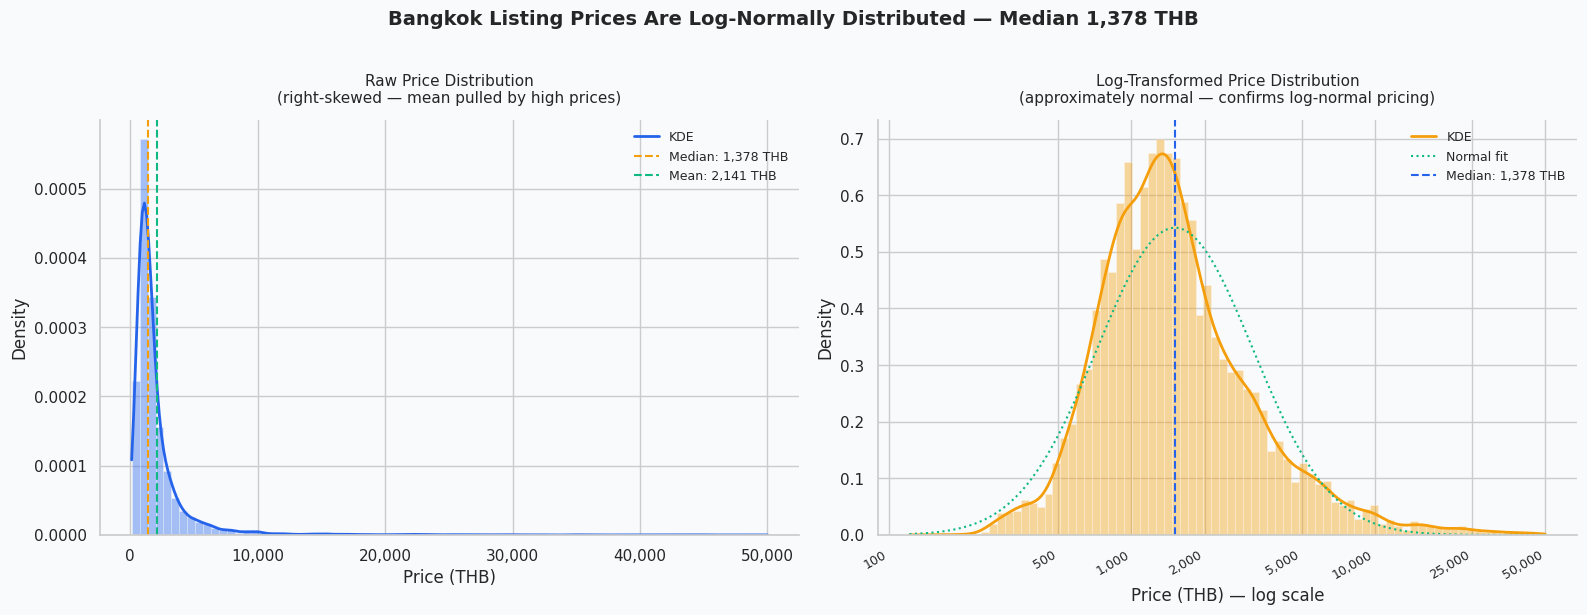

Skewness (raw):           6.86  (>1 = heavily right-skewed)
Skewness (log-transform): 0.86  (near 0 = approximately normal)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bangkok Listing Prices Are Log-Normally Distributed — Median 1,378 THB',
             fontsize=14, fontweight='bold', y=1.02)

# --- LEFT: Raw distribution with KDE ---
ax = axes[0]
price_data = listings_clean['price'].dropna()

ax.hist(price_data, bins=80, density=True,
        color=COLORS['primary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x = np.linspace(price_data.min(), price_data.max(), 300)
kde = stats.gaussian_kde(price_data)
ax.plot(kde_x, kde(kde_x), color=COLORS['primary'], linewidth=2, label='KDE')

median_price = price_data.median()
mean_price = price_data.mean()
ax.axvline(median_price, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')
ax.axvline(mean_price, color=COLORS['accent'], linewidth=1.5,
           linestyle='--', label=f'Mean: {mean_price:,.0f} THB')

ax.set_title('Raw Price Distribution\n(right-skewed — mean pulled by high prices)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(frameon=False, fontsize=9)

# --- RIGHT: Log scale with real currency labels ---
ax = axes[1]

# np.log1p(x) = log(1+x) — safely handles prices near 0 without returning -inf
log_price = np.log1p(price_data)

ax.hist(log_price, bins=80, density=True,
        color=COLORS['secondary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x_log = np.linspace(log_price.min(), log_price.max(), 300)
kde_log = stats.gaussian_kde(log_price)
ax.plot(kde_x_log, kde_log(kde_x_log), color=COLORS['secondary'], linewidth=2, label='KDE')

mu, std = log_price.mean(), log_price.std()
normal_curve = stats.norm.pdf(kde_x_log, mu, std)
ax.plot(kde_x_log, normal_curve, color=COLORS['accent'], linewidth=1.5,
        linestyle=':', label='Normal fit')

ax.axvline(mu, color=COLORS['primary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')

# Convert log tick positions back to real THB values for human readability
tick_positions = np.log1p([100, 500, 1000, 2000, 5000, 10000, 25000, 50000])
tick_labels = ['100', '500', '1,000', '2,000', '5,000', '10,000', '25,000', '50,000']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=9)

ax.set_title('Log-Transformed Price Distribution\n(approximately normal — confirms log-normal pricing)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB) — log scale')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Skewness (raw):           {price_data.skew():.2f}  (>1 = heavily right-skewed)")
print(f"Skewness (log-transform): {log_price.skew():.2f}  (near 0 = approximately normal)")

### Finding 1 — Price Distribution

Bangkok Airbnb prices are heavily right-skewed (skewness = 6.86), with most listings 
priced between 900–2,200 THB/night. The median (1,378 THB) is significantly lower than 
the mean (2,141 THB), indicating a small segment of premium listings pulling the average up.

Log-transformation reduces skewness to 0.86, confirming that prices follow a log-normal 
distribution — a common pattern in economic pricing data. A persistent right tail beyond 
the normal fit suggests a distinct premium listing segment that behaves differently from 
the broader market.

*All subsequent price analysis will use log-transformed values where statistical methods 
assume normality.*

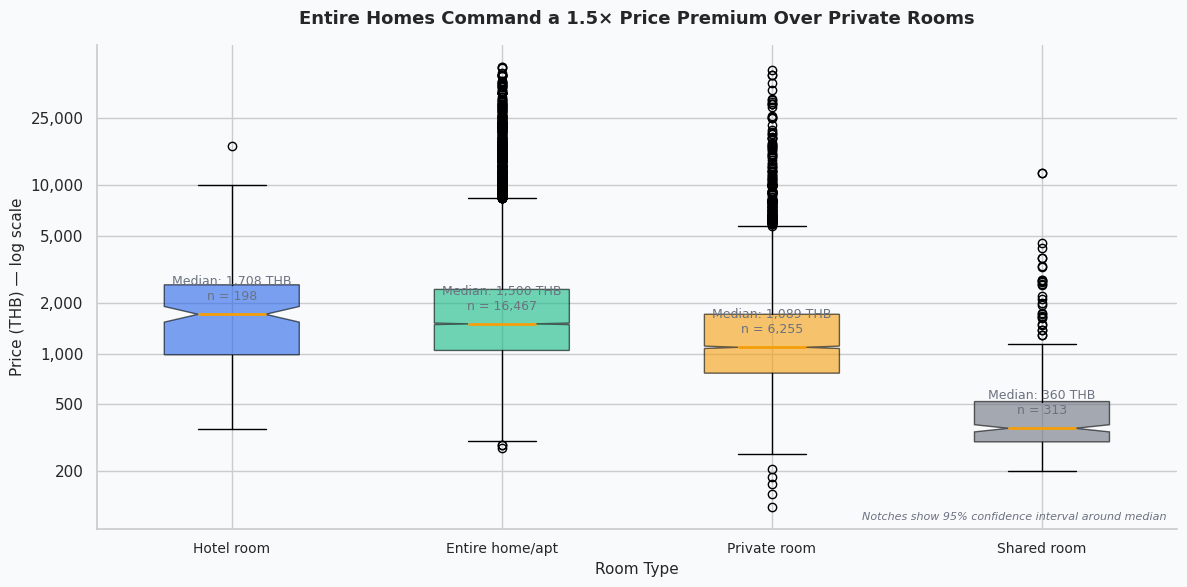

In [15]:
# Price by room type — boxplot with sample size annotations
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate median and count per room type for annotations
room_stats = (listings_clean
              .groupby('room_type')['price']
              .agg(['median', 'count'])
              .sort_values('median', ascending=False))

room_order = room_stats.index.tolist()

# Boxplot on log-transformed price
data_by_room = [np.log1p(listings_clean[listings_clean['room_type'] == r]['price'].dropna())
                for r in room_order]

bp = ax.boxplot(data_by_room,
                patch_artist=True,    # fills boxes with color
                notch=True,           # notch shows 95% CI around median
                vert=True,
                widths=0.5,
                medianprops=dict(color=COLORS['secondary'], linewidth=2))

# Apply color palette to boxes
box_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['neutral']]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Convert y-axis ticks back to real THB values
tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

# Annotate each box with median price and listing count
for i, room in enumerate(room_order):
    median = room_stats.loc[room, 'median']
    count  = room_stats.loc[room, 'count']
    ax.text(i + 1, np.log1p(median) + 0.15,
            f'Median: {median:,.0f} THB\nn = {count:,}',
            ha='center', va='bottom', fontsize=9,
            color=COLORS['neutral'])

ax.set_xticklabels(room_order, fontsize=10)
ax.set_title('Entire Homes Command a 1.5× Price Premium Over Private Rooms',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Price (THB) — log scale', fontsize=11)

# Notch explanation for readers unfamiliar with notched boxplots
ax.annotate('Notches show 95% confidence interval around median',
            xy=(0.99, 0.02), xycoords='axes fraction',
            ha='right', fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.show()

### Finding 2 — Price by Room Type

Entire homes/apartments dominate the Bangkok market (70% of listings) and command 
a 1.5× price premium over private rooms (median 1,500 vs 989 THB/night). 

Private rooms show the widest price variance, suggesting a split between budget 
guesthouses and premium private-room offerings. Shared rooms (360 THB median) and 
hotel rooms (198 listings) represent niche segments unlikely to affect market-wide 
pricing patterns.

*For subsequent price analysis, entire homes and private rooms will be analyzed 
separately where room type is a confounding variable.*

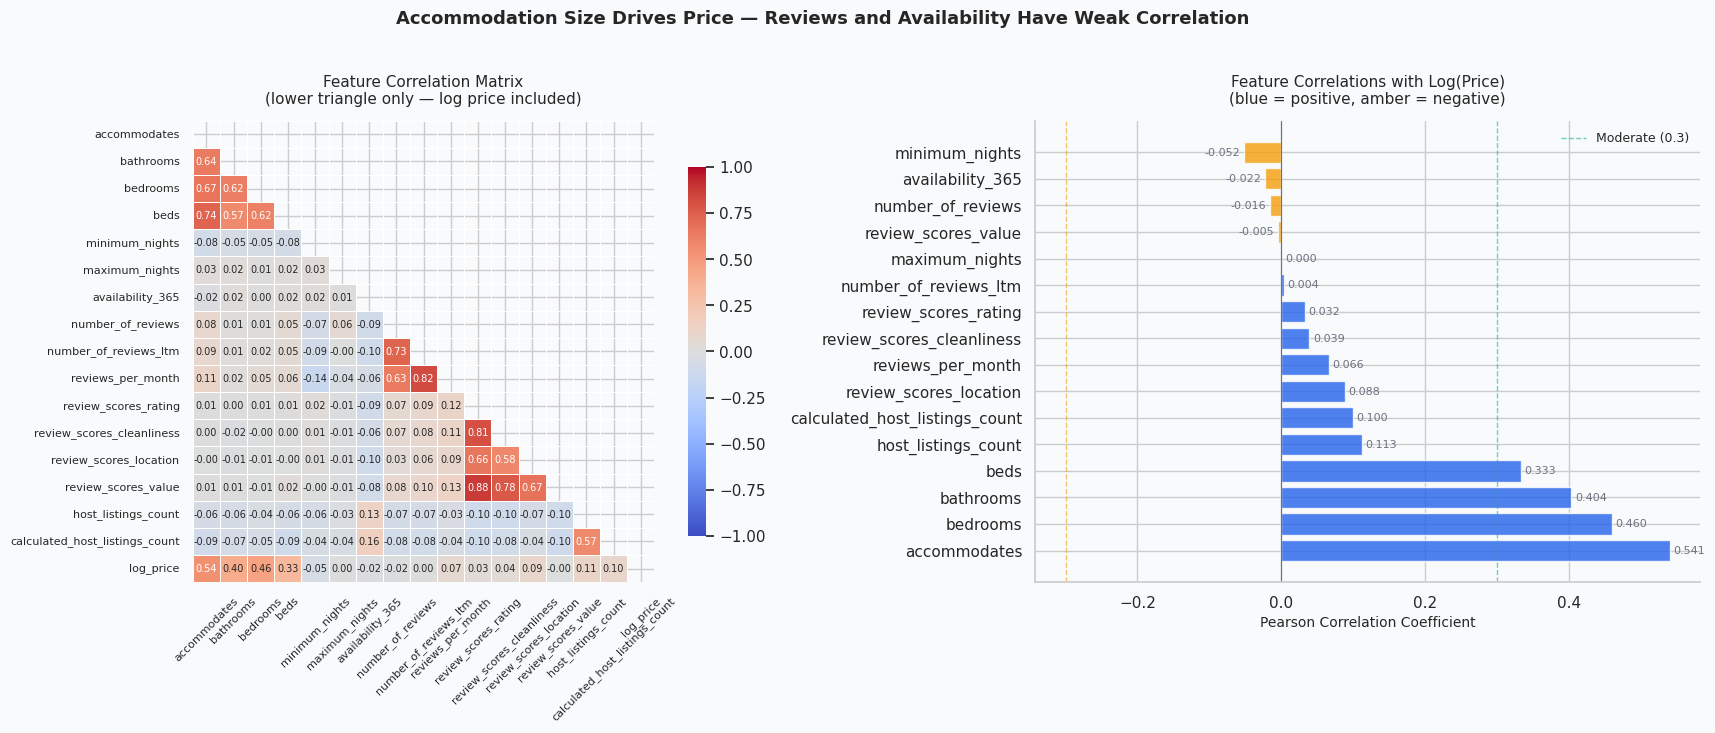

Top positive correlators with price:
accommodates           0.540979
bedrooms               0.459981
bathrooms              0.403838
beds                   0.333355
host_listings_count    0.112593

Top negative correlators with price:
Series([], )


In [16]:
# Select numeric columns relevant to price — exclude IDs, computed duplicates, availability variants
numeric_cols = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_listings_count', 'calculated_host_listings_count'
]

corr_df = listings_clean[numeric_cols].copy()

# Use log-transformed price for correlation — raw price correlations are 
# suppressed by skewness, log price reveals true linear relationships
corr_df['log_price'] = np.log1p(corr_df['price'])
corr_df = corr_df.drop(columns=['price'])

corr_matrix = corr_df.corr()

# Extract only correlations with log_price, sorted
price_corr = (corr_matrix['log_price']
              .drop('log_price')
              .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT: Full correlation heatmap ---
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle — avoid redundancy

sns.heatmap(corr_matrix,
            mask=mask,
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix\n(lower triangle only — log price included)',
             fontsize=11, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# --- RIGHT: Bar chart of correlations with log_price only ---
ax = axes[1]

colors = [COLORS['primary'] if v > 0 else COLORS['secondary'] for v in price_corr.values]
bars = ax.barh(price_corr.index, price_corr.values, color=colors, alpha=0.8, edgecolor='white')

# Annotate each bar with correlation value
for bar, val in zip(bars, price_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            color=COLORS['neutral'])

ax.axvline(0, color=COLORS['neutral'], linewidth=0.8, linestyle='-')

# Threshold lines — weak vs moderate correlation
ax.axvline(0.3,  color=COLORS['accent'],    linewidth=1, linestyle='--', alpha=0.6, label='Moderate (0.3)')
ax.axvline(-0.3, color=COLORS['secondary'], linewidth=1, linestyle='--', alpha=0.6)

ax.set_title('Feature Correlations with Log(Price)\n(blue = positive, amber = negative)',
             fontsize=11, pad=12)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=10)
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Accommodation Size Drives Price — Reviews and Availability Have Weak Correlation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print top drivers
print("Top positive correlators with price:")
print(price_corr[price_corr > 0.1].to_string())
print("\nTop negative correlators with price:")
print(price_corr[price_corr < -0.1].to_string())

In [17]:
print("ALL correlations with log_price (sorted):")
print(price_corr.sort_values().to_string())

ALL correlations with log_price (sorted):
minimum_nights                   -0.052346
availability_365                 -0.022485
number_of_reviews                -0.015580
review_scores_value              -0.004873
maximum_nights                    0.000249
number_of_reviews_ltm             0.003759
review_scores_rating              0.032490
review_scores_cleanliness         0.039186
reviews_per_month                 0.066205
review_scores_location            0.088383
calculated_host_listings_count    0.099536
host_listings_count               0.112593
beds                              0.333355
bathrooms                         0.403838
bedrooms                          0.459981
accommodates                      0.540979


### Finding 3 — Price Drivers (Correlation Analysis)

Accommodation size is the dominant price driver in Bangkok's Airbnb market.
The number of guests a listing accommodates (r=0.54), bedrooms (r=0.46),
bathrooms (r=0.40), and beds (r=0.33) are the four strongest correlates of price.

All other features show near-zero correlation with price (|r| < 0.12). Weak negative 
correlations appear for minimum_nights (-0.05) and availability_365 (-0.02), suggesting 
longer-stay and more-available listings price slightly lower — but these effects are 
negligible at the market level.

Review scores show no meaningful price correlation, suggesting quality acts as a 
threshold rather than a continuous price driver.

*Multicollinearity between size features means only one should be used as a predictor 
in any future regression model. `accommodates` is the recommended choice (highest r).*

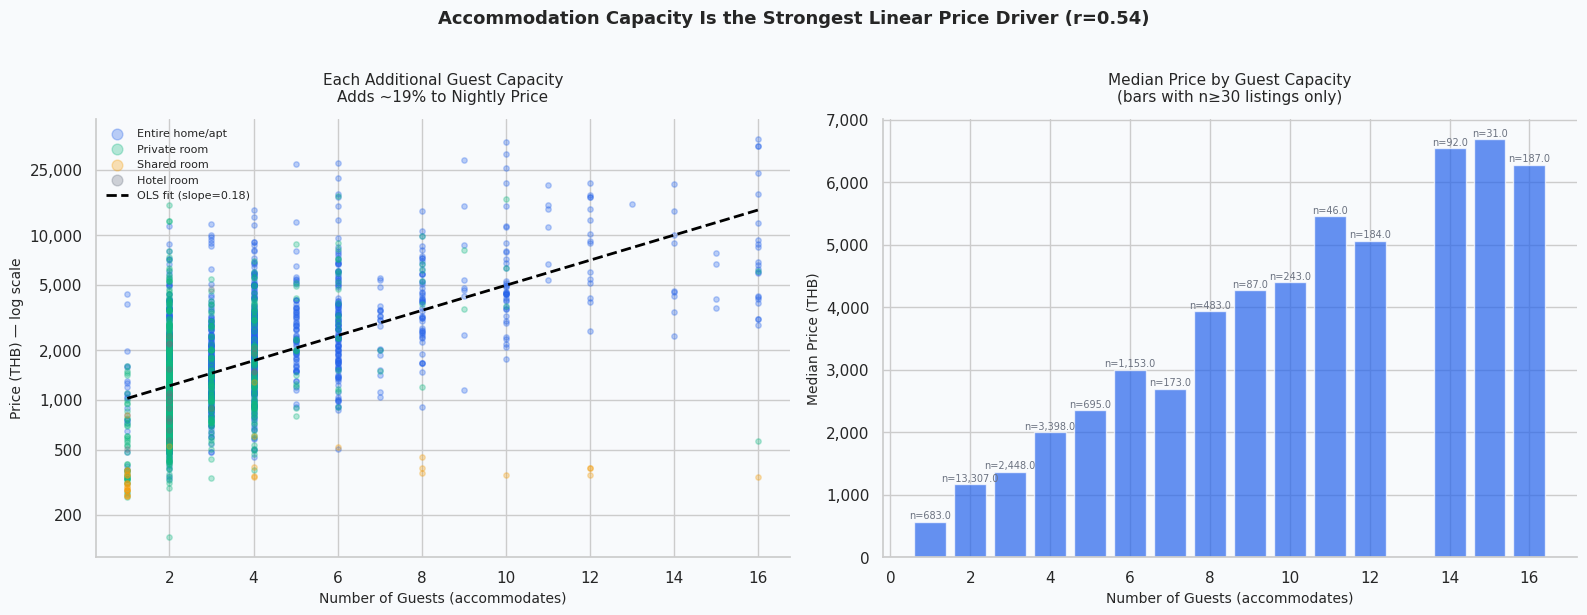

OLS slope: 0.176 in log scale
Interpretation: each additional guest capacity increases price by ~19.2%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: accommodates vs price scatter with regression line ---
ax = axes[0]

# Sample 3000 points — plotting all 23k points creates overplotting
# random_state ensures reproducibility
sample = listings_clean[['accommodates', 'price', 'room_type']].dropna().sample(3000, random_state=42)
log_sample_price = np.log1p(sample['price'])

# Scatter colored by room type
room_types = sample['room_type'].unique()
room_colors = {
    'Entire home/apt': COLORS['primary'],
    'Private room':    COLORS['accent'],
    'Shared room':     COLORS['secondary'],
    'Hotel room':      COLORS['neutral']
}

for room in room_types:
    mask = sample['room_type'] == room
    ax.scatter(sample.loc[mask, 'accommodates'],
               log_sample_price[mask],
               color=room_colors.get(room, COLORS['neutral']),
               alpha=0.3, s=15, label=room)

# OLS regression line
# np.polyfit fits a degree-1 polynomial (straight line) to the data
m, b = np.polyfit(sample['accommodates'], log_sample_price, 1)
x_line = np.linspace(sample['accommodates'].min(), sample['accommodates'].max(), 100)
ax.plot(x_line, m * x_line + b,
        color='black', linewidth=2, linestyle='--', label=f'OLS fit (slope={m:.2f})')

# Convert y ticks to real THB
tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

ax.set_title('Each Additional Guest Capacity\nAdds ~19% to Nightly Price',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Price (THB) — log scale', fontsize=10)
ax.legend(frameon=False, fontsize=8, markerscale=2)

# --- RIGHT: median price per accommodates value ---
ax = axes[1]

median_by_acc = (listings_clean
                 .groupby('accommodates')['price']
                 .agg(['median', 'count'])
                 .reset_index()
                 .query('count >= 30'))  # only show groups with enough data

ax.bar(median_by_acc['accommodates'], median_by_acc['median'],
       color=COLORS['primary'], alpha=0.7, edgecolor='white')

# Annotate count on each bar
for _, row in median_by_acc.iterrows():
    ax.text(row['accommodates'], row['median'] + 50,
            f"n={row['count']:,}",
            ha='center', fontsize=7, color=COLORS['neutral'])

ax.set_title('Median Price by Guest Capacity\n(bars with n≥30 listings only)',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Median Price (THB)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Accommodation Capacity Is the Strongest Linear Price Driver (r=0.54)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpret the slope
slope_pct = (np.exp(m) - 1) * 100
print(f"OLS slope: {m:.3f} in log scale")
print(f"Interpretation: each additional guest capacity increases price by ~{slope_pct:.1f}%")

### Finding 4 — Accommodation Capacity vs Price

Each additional guest capacity increases nightly price by approximately 19%, 
confirming accommodates as the strongest linear price driver (r=0.54). 
A listing for 4 guests has a median price of ~1,500 THB vs ~800 THB for 
a solo listing — nearly double.

The relationship holds consistently up to 10 guests but becomes unreliable 
beyond that due to thin sample sizes. Private rooms maintain a price ceiling 
regardless of capacity, suggesting room type acts as an upper bound on what 
the market will pay.

## Section 3 — Neighborhood Analysis
**Question: Which neighborhoods are most competitive in Bangkok?**

We'll analyze:
- Which neighborhoods have the most listings (supply)?
- Which neighborhoods command the highest prices?
- Is there a tradeoff between price and volume?
- Geographic distribution of prices across the city

In [20]:
# Neighborhood overview
neighbourhood_stats = (listings_clean
    .groupby('neighbourhood_cleansed')
    .agg(
        listing_count  = ('id', 'count'),
        median_price   = ('price', 'median'),
        mean_price     = ('price', 'mean'),
        avg_rating     = ('review_scores_rating', 'mean'),
        avg_avail_365  = ('availability_365', 'mean')
    )
    .round(1)
    .sort_values('listing_count', ascending=False)
    .reset_index()
)

print(f"Total neighbourhoods: {len(neighbourhood_stats)}")
print(f"\nTop 10 by listing count:")
print(neighbourhood_stats.head(10).to_string(index=False))

Total neighbourhoods: 50

Top 10 by listing count:
neighbourhood_cleansed  listing_count  median_price  mean_price  avg_rating  avg_avail_365
               Vadhana           3700        1823.5      3235.4         4.7          257.2
           Khlong Toei           3117        1622.0      2410.6         4.7          270.8
           Huai Khwang           3023        1400.0      1725.4         4.6          291.8
           Ratchathewi           1241        1586.0      2098.5         4.7          260.2
                Sathon           1090        1163.0      1941.0         4.7          276.5
          Phra Khanong           1001        1184.0      1591.3         4.7          279.0
           Phra Nakhon            923        1101.0      1564.5         4.7          311.8
              Bang Rak            755        1890.0      2753.8         4.8          260.3
             Suanluang            728        1045.0      1779.9         4.6          303.0
            Chatu Chak            681  

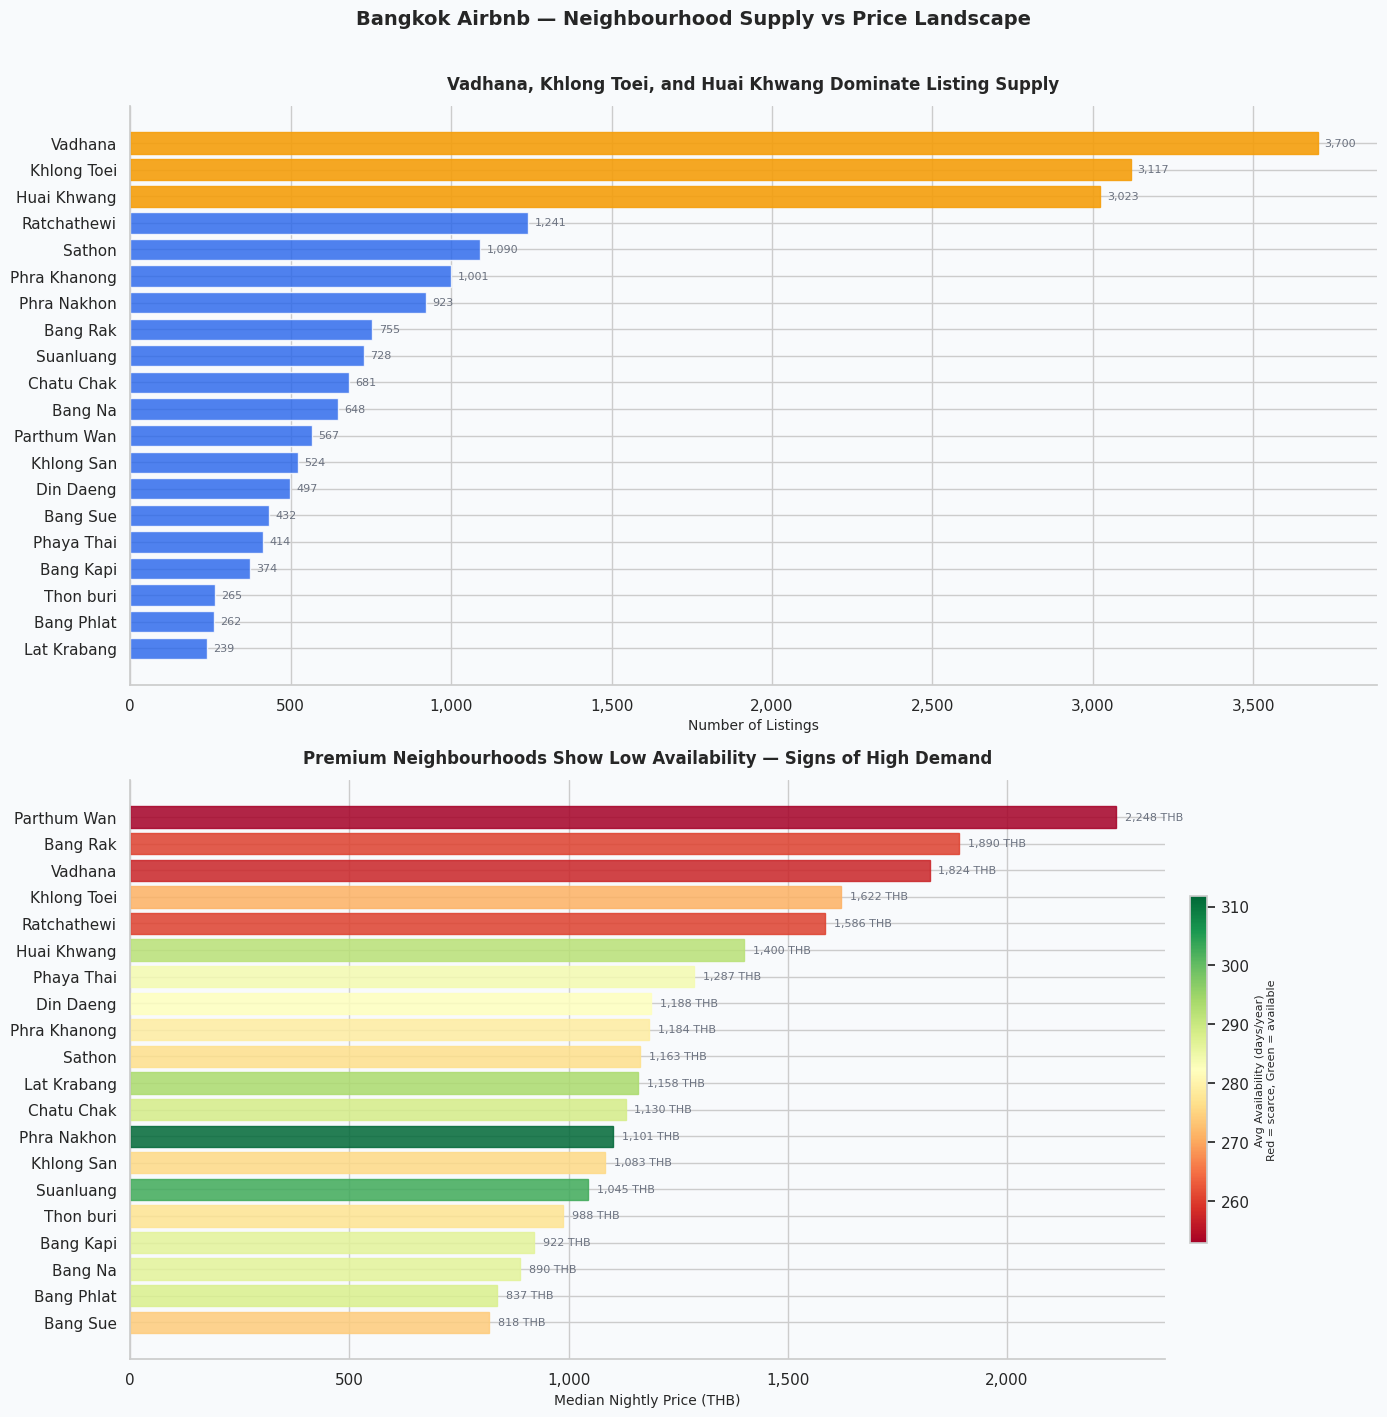

Correlation between median price and availability: -0.478

Most expensive neighbourhoods (top 5 by median price):
neighbourhood_cleansed  median_price  avg_avail_365
           Parthum Wan        2248.0          252.8
              Bang Rak        1890.0          260.3
        Samphanthawong        1879.0          290.3
               Vadhana        1823.5          257.2
           Khlong Toei        1622.0          270.8

Most affordable neighbourhoods (bottom 5 by median price):
neighbourhood_cleansed  median_price  avg_avail_365
            Nong Khaem         581.0          271.2
             Nong Chok         708.5          321.2
         Khlong Sam Wa         763.5          341.8
              Bang Bon         784.0          293.7
                Lak Si         800.0          306.2


In [21]:
# Use top 20 neighbourhoods for readability
top20 = neighbourhood_stats.head(20).copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# --- TOP: Listing count (supply) ---
ax = axes[0]

bars = ax.barh(top20['neighbourhood_cleansed'][::-1],
               top20['listing_count'][::-1],
               color=COLORS['primary'], alpha=0.8, edgecolor='white')

# Highlight top 3
for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color(COLORS['secondary'])
        bar.set_alpha(0.9)

# Annotate bars with count
for bar, val in zip(bars, top20['listing_count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Vadhana, Khlong Toei, and Huai Khwang Dominate Listing Supply',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Listings', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- BOTTOM: Median price with availability overlay ---
ax = axes[1]

# Sort by median price for this chart
top20_by_price = top20.sort_values('median_price', ascending=True)

bars = ax.barh(top20_by_price['neighbourhood_cleansed'],
               top20_by_price['median_price'],
               color=COLORS['primary'], alpha=0.7, edgecolor='white')

# Color bars by availability — highlights supply/demand tension
# Low availability + high price = high demand neighborhood
norm = plt.Normalize(top20_by_price['avg_avail_365'].min(),
                     top20_by_price['avg_avail_365'].max())
cmap = plt.cm.RdYlGn  # red=low availability, green=high availability

for bar, avail in zip(bars, top20_by_price['avg_avail_365']):
    bar.set_color(cmap(norm(avail)))
    bar.set_alpha(0.85)

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Avg Availability (days/year)\nRed = scarce, Green = available', fontsize=8)

# Annotate with median price
for bar, val in zip(bars, top20_by_price['median_price']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} THB', va='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Premium Neighbourhoods Show Low Availability — Signs of High Demand',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Median Nightly Price (THB)', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Bangkok Airbnb — Neighbourhood Supply vs Price Landscape',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print price vs availability correlation
corr = neighbourhood_stats['median_price'].corr(neighbourhood_stats['avg_avail_365'])
print(f"Correlation between median price and availability: {corr:.3f}")
print(f"\nMost expensive neighbourhoods (top 5 by median price):")
print(neighbourhood_stats.nlargest(5, 'median_price')[['neighbourhood_cleansed', 'median_price', 'avg_avail_365']].to_string(index=False))
print(f"\nMost affordable neighbourhoods (bottom 5 by median price):")
print(neighbourhood_stats.nsmallest(5, 'median_price')[['neighbourhood_cleansed', 'median_price', 'avg_avail_365']].to_string(index=False))

### Finding 5 — Neighbourhood Supply vs Price

Bangkok's Airbnb market shows a clear centre-periphery pricing structure. 
Central neighbourhoods (Parthum Wan, Bang Rak, Vadhana) command median prices 
of 1,800–2,250 THB/night, while peripheral areas (Nong Khaem, Nong Chok) 
price 3–4× lower at 580–710 THB/night.

A moderate negative correlation (r=-0.478) between median price and average 
availability confirms demand pressure in premium areas — expensive neighbourhoods 
get booked faster, leaving fewer available nights. 

Supply concentration does not equal price leadership: Vadhana, Khlong Toei, and 
Huai Khwang dominate listing volume but are not the most expensive neighbourhoods. 
Parthum Wan and Bang Rak achieve premium pricing with significantly fewer listings, 
suggesting scarcity and location quality matter more than supply volume.

In [22]:
# Merge neighbourhood stats with geojson for mapping
geo_df = neighbourhoods.merge(
    neighbourhood_stats[['neighbourhood_cleansed', 'median_price', 
                          'listing_count', 'avg_avail_365']],
    left_on='neighbourhood',   # column name in geojson
    right_on='neighbourhood_cleansed',
    how='left'
)

print(f"Geo dataframe shape: {geo_df.shape}")
print(f"Missing after merge: {geo_df['median_price'].isnull().sum()}")
print(geo_df[['neighbourhood', 'median_price', 'listing_count']].head())

Geo dataframe shape: (50, 7)
Missing after merge: 0
     neighbourhood  median_price  listing_count
0       Bang Phlat         837.0            262
1      Huai Khwang        1400.0           3023
2  Wang Thong Lang         958.0            142
3   Thawi Watthana        1060.0             21
4      Lat Krabang        1158.0            239


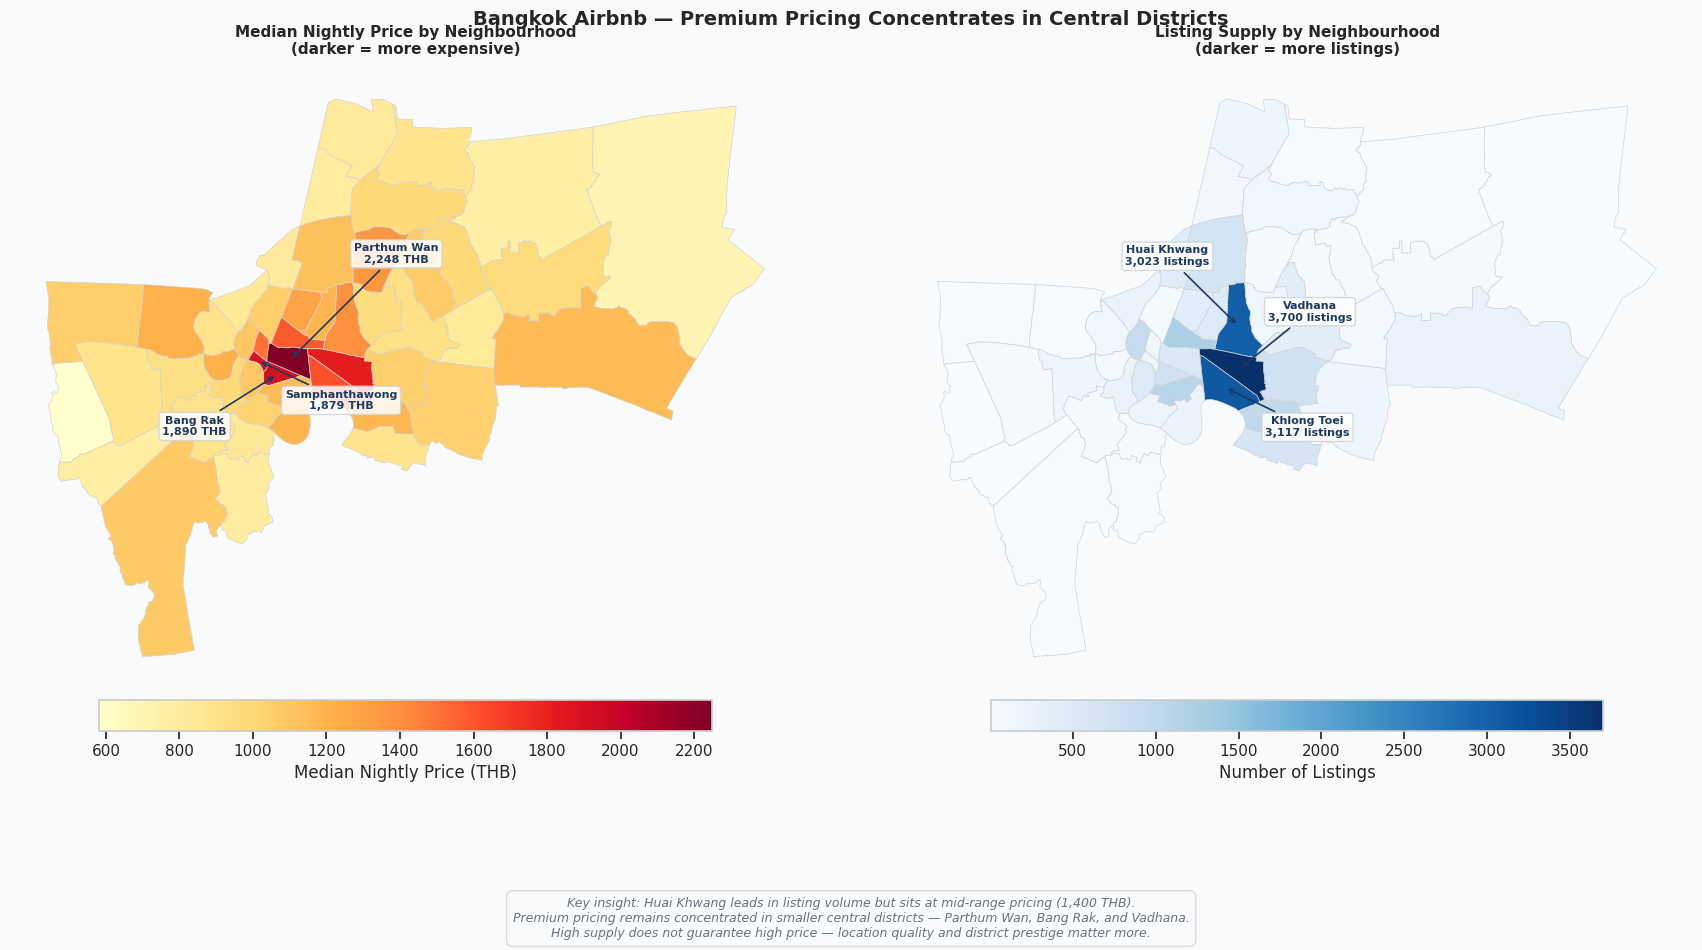

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- LEFT: Choropleth by median price ---
ax = axes[0]

geo_df.plot(
    column='median_price',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='lightgray',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Median Nightly Price (THB)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

# Annotate top 3 only — with arrows pulling labels outside dense center
top3_price = neighbourhood_stats.nlargest(3, 'median_price')
# Manual offsets to avoid overlap — tuned for Bangkok's geography
label_offsets = {
    'Parthum Wan':     (0.09,  0.08),
    'Bang Rak':        (-0.07, -0.05),
    'Samphanthawong':  (0.07, -0.04),
}

for _, row in top3_price.iterrows():
    name = row['neighbourhood_cleansed']
    centroid = geo_df[geo_df['neighbourhood_cleansed'] == name].geometry.centroid
    if not centroid.empty:
        cx, cy = centroid.x.values[0], centroid.y.values[0]
        dx, dy = label_offsets.get(name, (0.05, 0.05))
        ax.annotate(
            f"{name}\n{row['median_price']:,.0f} THB",
            xy=(cx, cy),
            xytext=(cx + dx, cy + dy),
            fontsize=8,
            fontweight='bold',
            ha='center',
            color='#1E3A5F',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     alpha=0.85, edgecolor='lightgray'),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=1.2)
        )

ax.set_title('Median Nightly Price by Neighbourhood\n(darker = more expensive)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_axis_off()

# --- RIGHT: Choropleth by listing count ---
ax = axes[1]

geo_df.plot(
    column='listing_count',
    ax=ax,
    cmap='Blues',
    edgecolor='lightgray',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Number of Listings',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

# Annotate top 3 by volume only
top3_volume = neighbourhood_stats.nlargest(3, 'listing_count')
volume_offsets = {
    'Vadhana':      (0.06,  0.04),
    'Khlong Toei':  (0.07, -0.04),
    'Huai Khwang':  (-0.06, 0.05),
}

for _, row in top3_volume.iterrows():
    name = row['neighbourhood_cleansed']
    centroid = geo_df[geo_df['neighbourhood_cleansed'] == name].geometry.centroid
    if not centroid.empty:
        cx, cy = centroid.x.values[0], centroid.y.values[0]
        dx, dy = volume_offsets.get(name, (0.05, 0.05))
        ax.annotate(
            f"{name}\n{row['listing_count']:,} listings",
            xy=(cx, cy),
            xytext=(cx + dx, cy + dy),
            fontsize=8,
            fontweight='bold',
            ha='center',
            color='#1E3A5F',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     alpha=0.85, edgecolor='lightgray'),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=1.2)
        )

ax.set_title('Listing Supply by Neighbourhood\n(darker = more listings)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_axis_off()

# Synchronized story caption linking both maps
fig.text(0.5, -0.02,
         'Key insight: Huai Khwang leads in listing volume but sits at mid-range pricing (1,400 THB).\n'
         'Premium pricing remains concentrated in smaller central districts — Parthum Wan, Bang Rak, and Vadhana.\n'
         'High supply does not guarantee high price — location quality and district prestige matter more.',
         ha='center', fontsize=9, style='italic', color=COLORS['neutral'],
         bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['background'], 
                  edgecolor='lightgray', alpha=0.8))

plt.suptitle('Bangkok Airbnb — Premium Pricing Concentrates in Central Districts',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

### Finding 6 — Neighbourhood Analysis

Bangkok's Airbnb market follows a clear centre-periphery structure. Premium pricing 
concentrates in small central districts — Parthum Wan (2,248 THB), Bang Rak (1,890 THB), 
and Samphanthawong (1,879 THB) — while peripheral neighbourhoods price 3–4× lower 
(Nong Khaem: 581 THB, Nong Chok: 709 THB).

A moderate negative correlation (r=-0.478) between median price and availability 
confirms demand pressure in premium areas — expensive neighbourhoods get booked faster, 
leaving fewer available nights per year.

Critically, high supply does not equal high price. Huai Khwang leads the market in 
listing volume (3,023 listings) but sits at mid-range pricing (1,400 THB). Premium 
pricing is driven by location quality and district prestige, not listing density.

*Hosts in peripheral neighbourhoods should not compete on price alone — proximity 
to transit and tourist attractions may be a stronger differentiator than cost.*

## Section 4 — Host Analysis
**Question: What makes a high-performing host in Bangkok?**

We define "high-performing" as hosts with both a high review score AND 
a high number of reviews — quality AND consistency, not just one or the other.

We'll analyze:
- Superhost vs non-superhost: price, reviews, response rate
- Multi-listing hosts vs single hosts
- Does response time affect review scores?
- What separates top hosts from average ones?

In [26]:
# Host overview
print("Superhost distribution:")
print(listings_clean['host_is_superhost'].value_counts())
print(f"\nMissing superhost flag: {listings_clean['host_is_superhost'].isnull().sum()}")

print("\nResponse time distribution:")
print(listings_clean['host_response_time'].value_counts())

print(f"\nUnique hosts in dataset: {listings_clean['host_id'].nunique()}")
print(f"Total listings: {len(listings_clean)}")
print(f"Avg listings per host: {len(listings_clean) / listings_clean['host_id'].nunique():.2f}")

Superhost distribution:
host_is_superhost
f    14344
t     7416
Name: count, dtype: int64

Missing superhost flag: 1473

Response time distribution:
host_response_time
within an hour        16346
within a few hours     2122
a few days or more     1021
within a day           1002
Name: count, dtype: int64

Unique hosts in dataset: 6649
Total listings: 23233
Avg listings per host: 3.49


In [27]:
# Convert t/f flags to boolean for cleaner analysis
listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].map({'t': True, 'f': False})
listings_clean['instant_bookable'] = listings_clean['instant_bookable'].map({'t': True, 'f': False})

# Convert response rate from string percentage to float
listings_clean['host_response_rate'] = (listings_clean['host_response_rate']
                                         .str.replace('%', '', regex=False)
                                         .astype(float))

listings_clean['host_acceptance_rate'] = (listings_clean['host_acceptance_rate']
                                           .str.replace('%', '', regex=False)
                                           .astype(float))

# Define high-performing hosts:
# top 25% in review score AND top 25% in number of reviews
rating_threshold  = listings_clean['review_scores_rating'].quantile(0.75)
reviews_threshold = listings_clean['number_of_reviews'].quantile(0.75)

listings_clean['is_high_performer'] = (
    (listings_clean['review_scores_rating'] >= rating_threshold) &
    (listings_clean['number_of_reviews']    >= reviews_threshold)
)

print(f"Rating threshold (75th percentile):  {rating_threshold}")
print(f"Reviews threshold (75th percentile): {reviews_threshold}")
print(f"\nHigh performers: {listings_clean['is_high_performer'].sum():,}")
print(f"Percentage: {listings_clean['is_high_performer'].mean()*100:.1f}%")

Rating threshold (75th percentile):  5.0
Reviews threshold (75th percentile): 21.0

High performers: 204
Percentage: 0.9%


In [28]:
# Rating compression check
print("Review score distribution:")
print(listings_clean['review_scores_rating'].describe())
print(f"\nListings with perfect 5.0 rating: {(listings_clean['review_scores_rating'] == 5.0).sum():,}")
print(f"Listings with rating >= 4.8:       {(listings_clean['review_scores_rating'] >= 4.8).sum():,}")
print(f"Listings with rating >= 4.5:       {(listings_clean['review_scores_rating'] >= 4.5).sum():,}")
print(f"\nValue counts (top 10):")
print(listings_clean['review_scores_rating'].value_counts().head(10))

Review score distribution:
count    16093.000000
mean         4.714595
std          0.506214
min          1.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

Listings with perfect 5.0 rating: 5,148
Listings with rating >= 4.8:       9,693
Listings with rating >= 4.5:       13,908

Value counts (top 10):
review_scores_rating
5.00    5148
4.00     498
4.50     478
4.67     447
4.75     376
4.88     372
4.80     370
4.83     365
4.86     335
4.89     296
Name: count, dtype: int64


In [29]:
# Rating is compressed — 60% of rated listings score above 4.8
# We redefine high performer using metrics with real variance:
# - number of reviews (volume = proven track record)
# - reviews per month (consistency = actively hosting)
# - host_is_superhost (Airbnb's own quality signal)

print("Reviews per month distribution:")
print(listings_clean['reviews_per_month'].describe().round(2))
print(f"\nSuperhost AND high review volume:")

# New definition: superhost + top 25% reviews count
reviews_threshold = listings_clean['number_of_reviews'].quantile(0.75)

listings_clean['is_high_performer'] = (
    (listings_clean['host_is_superhost'] == True) &
    (listings_clean['number_of_reviews'] >= reviews_threshold)
)

print(f"Reviews threshold (75th percentile): {reviews_threshold:.0f} reviews")
print(f"High performers: {listings_clean['is_high_performer'].sum():,}")
print(f"Percentage of listings: {listings_clean['is_high_performer'].mean()*100:.1f}%")

# Also check superhost alone
print(f"\nSuperhost only: {(listings_clean['host_is_superhost']==True).sum():,}")
print(f"Non-superhost:  {(listings_clean['host_is_superhost']==False).sum():,}")

Reviews per month distribution:
count    16093.00
mean         1.06
std          1.55
min          0.01
25%          0.22
50%          0.58
75%          1.40
max         57.60
Name: reviews_per_month, dtype: float64

Superhost AND high review volume:
Reviews threshold (75th percentile): 21 reviews
High performers: 2,940
Percentage of listings: 12.7%

Superhost only: 7,416
Non-superhost:  14,344


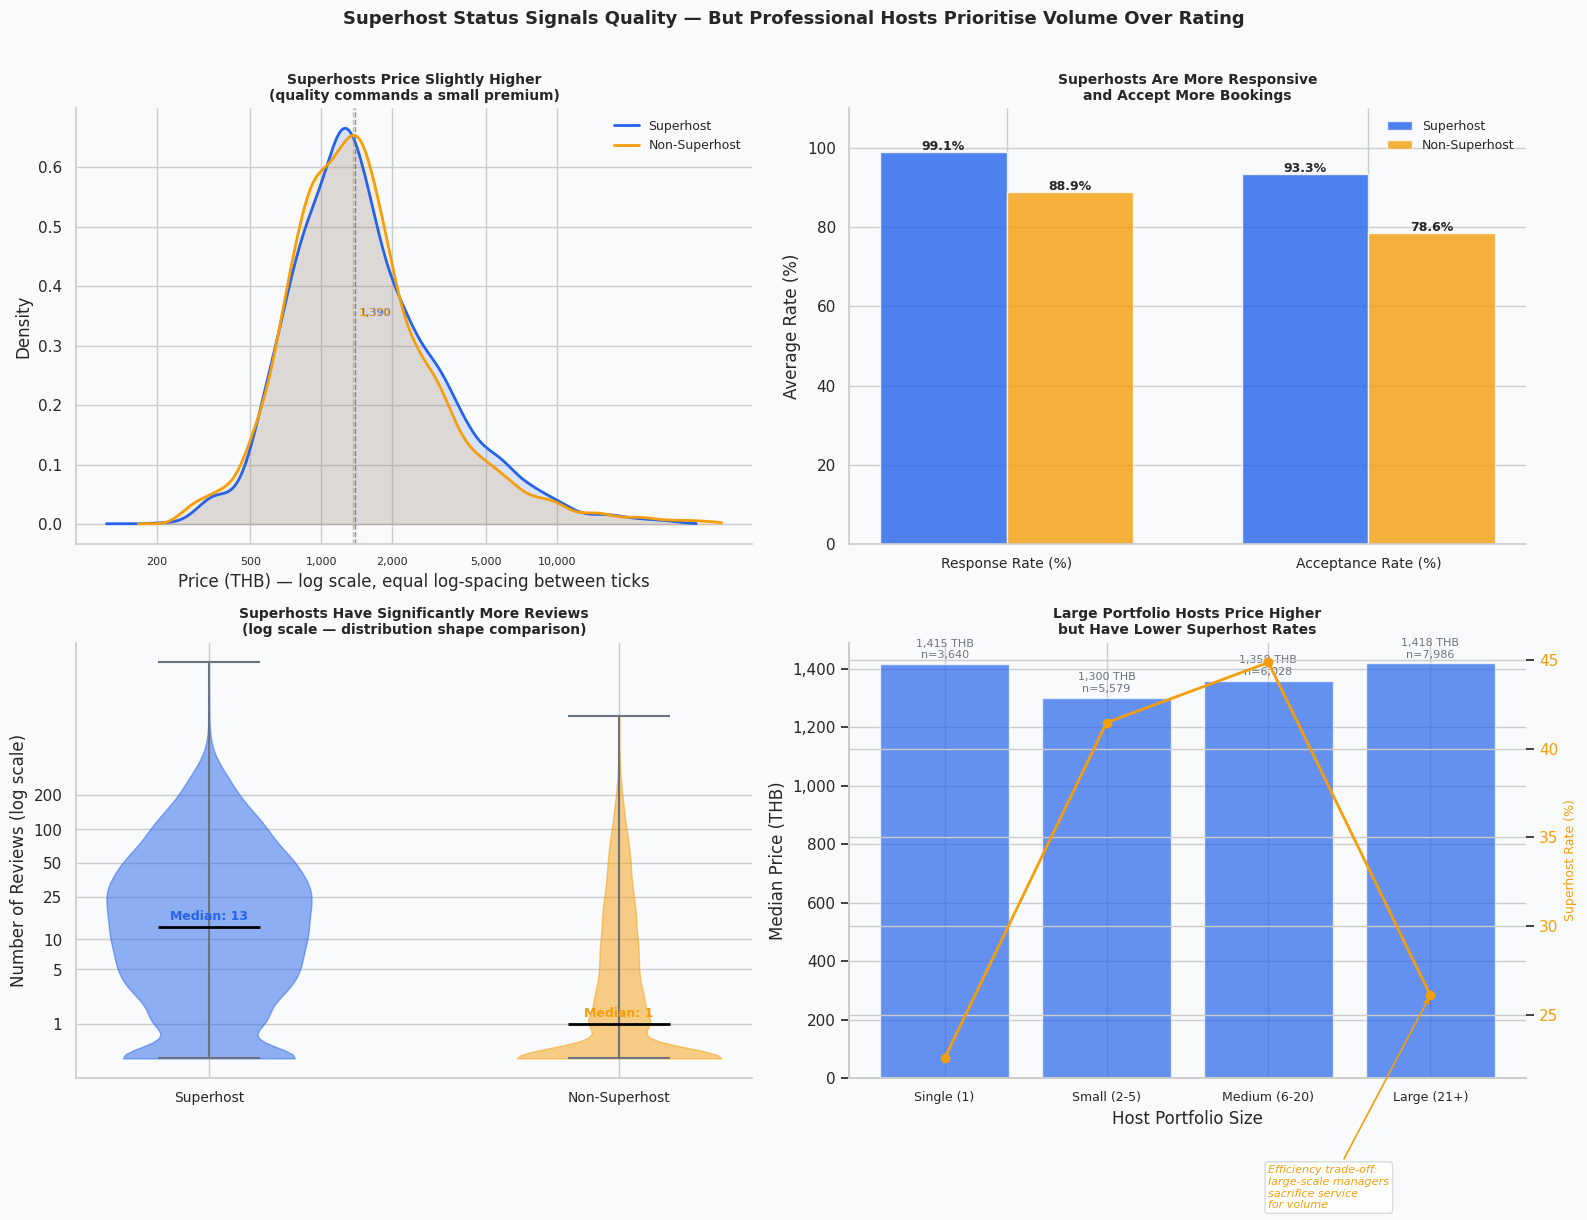

Superhost vs Non-Superhost summary:

Superhost:
  Median price:        1,390 THB
  Avg response rate:   99.1%
  Avg acceptance rate: 93.3%
  Median reviews:      13

Non-Superhost:
  Median price:        1,370 THB
  Avg response rate:   88.9%
  Avg acceptance rate: 78.6%
  Median reviews:      1


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_sh = [COLORS['primary'], COLORS['secondary']]

# --- TOP LEFT: Price distribution by superhost status ---
ax = axes[0, 0]

for (label, group), color in zip(superhost_groups.items(), colors_sh):
    log_prices = np.log1p(group['price'].dropna())
    kde_x = np.linspace(log_prices.min(), log_prices.max(), 300)
    kde = stats.gaussian_kde(log_prices)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.15, color=color)
    median = group['price'].median()
    ax.axvline(np.log1p(median), color=color, linewidth=1,
               linestyle='--', alpha=0.7)
    ax.text(np.log1p(median) + 0.05, ax.get_ylim()[1] * 0.5,
            f'{median:,.0f}', fontsize=8, color=color)

# Log-spaced ticks — distances are equal in log space
tick_values    = [200, 500, 1000, 2000, 5000, 10000]
tick_positions = np.log1p(tick_values)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'{v:,}' for v in tick_values], fontsize=8)

ax.set_title('Superhosts Price Slightly Higher\n(quality commands a small premium)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Price (THB) — log scale, equal log-spacing between ticks')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

# --- TOP RIGHT: Response rate comparison ---
ax = axes[0, 1]

metrics = ['host_response_rate', 'host_acceptance_rate']
labels  = ['Response Rate (%)', 'Acceptance Rate (%)']
x = np.arange(len(metrics))
width = 0.35

for i, (label, group) in enumerate(superhost_groups.items()):
    vals = [group[m].mean() for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=label, color=colors_sh[i], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 110)
ax.set_title('Superhosts Are More Responsive\nand Accept More Bookings',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Average Rate (%)')
ax.legend(frameon=False, fontsize=9)

# --- BOTTOM LEFT: Violin plot replacing histogram ---
ax = axes[1, 0]

violin_data = [
    np.log1p(superhost_groups['Superhost']['number_of_reviews'].dropna()),
    np.log1p(superhost_groups['Non-Superhost']['number_of_reviews'].dropna())
]

parts = ax.violinplot(violin_data, positions=[1, 2],
                      showmedians=True, showextrema=True)

# Style each violin
for i, (pc, color) in enumerate(zip(parts['bodies'], colors_sh)):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
    pc.set_edgecolor(color)

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cbars'].set_color(COLORS['neutral'])
parts['cmaxes'].set_color(COLORS['neutral'])
parts['cmins'].set_color(COLORS['neutral'])

# Overlay individual medians as annotations
for i, (label, group) in enumerate(superhost_groups.items(), 1):
    median = group['number_of_reviews'].median()
    ax.text(i, np.log1p(median) + 0.15,
            f'Median: {median:.0f}',
            ha='center', fontsize=9, fontweight='bold',
            color=colors_sh[i-1])

# Convert y ticks back to real review counts
tick_vals = [1, 5, 10, 25, 50, 100, 200]
ax.set_yticks(np.log1p(tick_vals))
ax.set_yticklabels(tick_vals)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Superhost', 'Non-Superhost'], fontsize=10)
ax.set_title('Superhosts Have Significantly More Reviews\n(log scale — distribution shape comparison)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Reviews (log scale)')

# --- BOTTOM RIGHT: Multi-listing hosts ---
ax = axes[1, 1]

host_cat_stats = (listings_clean
    .groupby('host_category', observed=True)
    .agg(
        median_price   = ('price', 'median'),
        superhost_rate = ('host_is_superhost', 'mean'),
        count          = ('id', 'count')
    )
    .reset_index()
)

x = np.arange(len(host_cat_stats))
bars = ax.bar(x, host_cat_stats['median_price'],
              color=COLORS['primary'], alpha=0.7, edgecolor='white')

ax2 = ax.twinx()
ax2.plot(x, host_cat_stats['superhost_rate'] * 100,
         color=COLORS['secondary'], linewidth=2,
         marker='o', markersize=6, label='Superhost Rate (%)')
ax2.set_ylabel('Superhost Rate (%)', color=COLORS['secondary'], fontsize=9)
ax2.tick_params(axis='y', labelcolor=COLORS['secondary'])

# Annotate bars
for bar, val, count in zip(bars, host_cat_stats['median_price'],
                            host_cat_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val:,.0f} THB\nn={count:,}',
            ha='center', fontsize=8, color=COLORS['neutral'])

# Annotate the superhost rate drop for Large hosts — killer insight
large_idx = len(host_cat_stats) - 1
large_sh_rate = host_cat_stats['superhost_rate'].iloc[large_idx] * 100
ax2.annotate(
    'Efficiency trade-off:\nlarge-scale managers\nsacrifice service\nfor volume',
    xy=(large_idx, large_sh_rate),
    xytext=(large_idx - 1.0, large_sh_rate - 12),
    fontsize=8,
    color=COLORS['secondary'],
    style='italic',
    arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              alpha=0.85, edgecolor='lightgray')
)

ax.set_xticks(x)
ax.set_xticklabels(host_cat_stats['host_category'], fontsize=9)
ax.set_title('Large Portfolio Hosts Price Higher\nbut Have Lower Superhost Rates',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Host Portfolio Size')
ax.set_ylabel('Median Price (THB)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Superhost Status Signals Quality — But Professional Hosts Prioritise Volume Over Rating',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Superhost vs Non-Superhost summary:")
for label, group in superhost_groups.items():
    print(f"\n{label}:")
    print(f"  Median price:        {group['price'].median():,.0f} THB")
    print(f"  Avg response rate:   {group['host_response_rate'].mean():.1f}%")
    print(f"  Avg acceptance rate: {group['host_acceptance_rate'].mean():.1f}%")
    print(f"  Median reviews:      {group['number_of_reviews'].median():.0f}")

### Finding 7 — Host Performance Analysis

Superhost status signals operational excellence, not premium pricing. 
Superhosts and non-superhosts price nearly identically (median 1,390 vs 1,370 THB), 
but superhosts respond to 99.1% of inquiries vs 88.9% for non-superhosts, and 
accept 93.3% of booking requests vs 78.6% — a 15-point gap that directly impacts 
occupancy rates.

The review volume gap is striking: superhosts have a median of 13 reviews vs 1 for 
non-superhosts, confirming that superhost status reflects an established track record 
rather than just quality scores.

A notable efficiency trade-off emerges at scale: large portfolio hosts (21+ listings) 
achieve the highest median prices (1,418 THB) but have the lowest superhost rate (26%), 
suggesting that professional property managers optimise for volume over the personalised 
service Airbnb's superhost criteria rewards.

*For new hosts: achieving superhost status requires responsiveness and acceptance rate 
consistency more than premium pricing — operational habits matter more than listing quality.*